In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import plotly.graph_objects as go

from sklearn.metrics import root_mean_squared_error

In [2]:
N_TRIALS = 100

ACTIVATIONS: dict[str, type[nn.Module]] = {
    "relu": nn.ReLU,
    "gelu": nn.GELU,
    "silu": nn.SiLU, # swish
    "sigmoid": nn.Sigmoid,
}

In [3]:
def training_data(N: int = 10, seed: int = 37):
    np.random.seed(seed)
    X = np.random.randint(1, 7, size=(N, 5)).astype(float)
    X_petals = np.where(X == 3, 2, 0) + np.where(X == 5, 4, 0)
    y = X_petals.sum(axis=1).astype(float)

    return X, y

X_train, y_train = training_data(1_000, seed=37)
X_valid, y_valid = training_data(1_000, seed=42)

Text(0.5, 1.0, 'Dice Rolls vs. Petals')

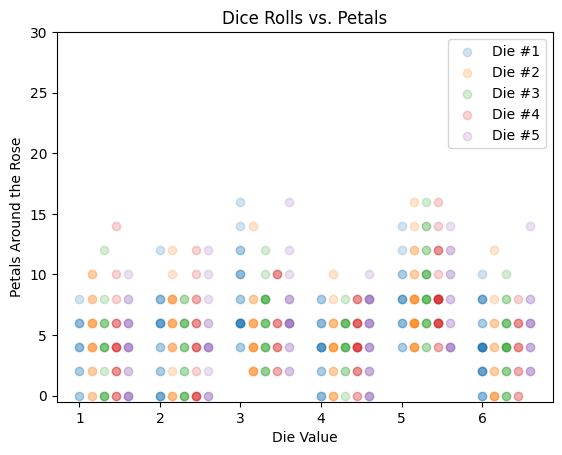

In [4]:
for index in range(X_train.shape[1]):
    plt.scatter(X_train[:100, index] + 0.15*index, y_train[:100], alpha=0.2, label=f"Die #{index+1}")
plt.ylim(-0.5, 30)
plt.legend()
plt.ylabel("Petals Around the Rose")
plt.xlabel("Die Value")
plt.title("Dice Rolls vs. Petals")

In [5]:
class FCNet(nn.Module):
    def __init__(
        self,
        hidden_1: int,
        hidden_2: int,
        activation: type[nn.Module],
    ):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, hidden_1),
            nn.BatchNorm1d(hidden_1),
            activation(),
            nn.Linear(hidden_1, hidden_2),
            nn.BatchNorm1d(hidden_2),
            activation(),
            nn.Linear(hidden_2, 1),
        )

    def forward(self, X):
        return self.net(X)


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.1)
        nn.init.constant_(m.bias, 0.0)

In [6]:
def calculate_metrics(y_true: np.ndarray, y_hat: np.ndarray):
    y_prediction = np.rint(y_hat)
    return {
        "rmse": root_mean_squared_error(y_true, y_hat),
        "mae": np.mean(np.abs(y_hat - y_true)),
        "bias": np.mean(y_hat - y_true),
        "accuracy": np.mean(y_prediction == y_true),
        "accuracy_pm1": np.mean(np.abs(y_prediction - y_true) <= 1),
    }

In [7]:
class FCNNRegressor:
    def __init__(
        self,
        *,
        hidden_1: int = 100,
        hidden_2: int = 10,
        learning_rate: float = 0.01,
        activation: type[nn.Module] = nn.ReLU,
        batch_size: int = 1024,
        epochs: int = 2_000,
        seed: int = 37,
    ):
        self.hidden_1 = hidden_1
        self.hidden_2 = hidden_2
        self.learning_rate = learning_rate
        self.activation = activation
        self.batch_size = batch_size
        self.epochs = epochs
        self.seed = seed

        self.model = None
        self.history = []

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.1)
            nn.init.constant_(module.bias, 0.0)

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.history = []

        torch.manual_seed(self.seed)

        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

        self.model = FCNet(
            hidden_1=self.hidden_1,
            hidden_2=self.hidden_2,
            activation=self.activation,
        )
        self.model.apply(self._init_weights)

        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        loss_function = nn.MSELoss()

        train_dataset = TensorDataset(X_tensor, y_tensor)
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True
        )
        
        for epoch in range(self.epochs):
            # train
            self.model.train()
            epoch_losses = []
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                y_hat = self.model(X_batch)
                loss = loss_function(y_hat, y_batch)
                loss.backward()
                optimizer.step()
                epoch_losses.append(float(loss.detach().cpu()))

            # evaluate
            self.model.eval()
            with torch.no_grad():
                y_hat = self.model(X_tensor).numpy().ravel()

            # log metrics
            self.history.append({
                "epoch": epoch,
                "loss": np.mean(epoch_losses),
                **calculate_metrics(y, y_hat),
            })

        return self

    def predict(self, X: np.ndarray | torch.Tensor) -> np.ndarray:
        if self.model is None:
            raise RuntimeError("Model must be fit before calling predict().")
    
        self.model.eval()
    
        if isinstance(X, np.ndarray):
            X_tensor = torch.tensor(X, dtype=torch.float32)
        elif isinstance(X, torch.Tensor):
            X_tensor = X.to(dtype=torch.float32)
        else:
            raise TypeError("X must be a numpy array or torch tensor.")
    
        with torch.no_grad():
            y_hat = self.model(X_tensor)
    
        return y_hat.detach().cpu().numpy().ravel()

In [8]:
def objective(trial):
    hidden_1 = trial.suggest_int("hidden_1", 8, 1024)
    hidden_2 = trial.suggest_int("hidden_2", 1, min(256, hidden_1))
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512, 1024])
    activation_name = trial.suggest_categorical("activation", ["relu", "gelu", "silu", "sigmoid"])

    model = FCNNRegressor(
        hidden_1=hidden_1,
        hidden_2=hidden_2,
        learning_rate=learning_rate,
        batch_size=batch_size,
        activation=ACTIVATIONS[activation_name],
        epochs=2_000,
    )
    model.fit(X_train, y_train)

    y_hat = model.predict(X_valid)
    metrics = calculate_metrics(y_valid, y_hat)
    for metric, value in metrics.items():
        trial.set_user_attr(metric, value)
    
    return metrics["rmse"]

In [9]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=37),
)

[I 2026-05-24 12:06:49,897] A new study created in memory with name: no-name-bcdc1f3b-023b-47b0-a328-fc7734d46cea


In [10]:
study.optimize(objective, n_trials=N_TRIALS)

print("Best parameters:")
print(study.best_params)

print("\nBest RMSE:")
print(study.best_value)

print("\nBest accuracy:")
print(study.best_trial.user_attrs["accuracy"])

[I 2026-05-24 12:07:26,748] Trial 0 finished with value: 2.665375222582283 and parameters: {'hidden_1': 968, 'hidden_2': 119, 'learning_rate': 0.0003787782967895686, 'batch_size': 1024, 'activation': 'silu'}. Best is trial 0 with value: 2.665375222582283.
[I 2026-05-24 12:08:01,295] Trial 1 finished with value: 0.282480436429467 and parameters: {'hidden_1': 459, 'hidden_2': 247, 'learning_rate': 0.04911336164589855, 'batch_size': 1024, 'activation': 'sigmoid'}. Best is trial 1 with value: 0.282480436429467.
[I 2026-05-24 12:09:01,060] Trial 2 finished with value: 1.2527416718108473 and parameters: {'hidden_1': 825, 'hidden_2': 249, 'learning_rate': 0.0009975571293448003, 'batch_size': 256, 'activation': 'sigmoid'}. Best is trial 1 with value: 0.282480436429467.
[I 2026-05-24 12:09:28,240] Trial 3 finished with value: 0.3013992008923177 and parameters: {'hidden_1': 659, 'hidden_2': 5, 'learning_rate': 0.026188770817096668, 'batch_size': 1024, 'activation': 'relu'}. Best is trial 1 with 

Best parameters:
{'hidden_1': 755, 'hidden_2': 132, 'learning_rate': 0.07647944640577382, 'batch_size': 256, 'activation': 'sigmoid'}

Best RMSE:
0.0115186379267004

Best accuracy:
1.0


In [11]:
print("Best parameters:")
print(study.best_params)

print("\nBest RMSE:")
print(study.best_value)

print("\nBest accuracy:")
print(study.best_trial.user_attrs["accuracy"])

Best parameters:
{'hidden_1': 755, 'hidden_2': 132, 'learning_rate': 0.07647944640577382, 'batch_size': 256, 'activation': 'sigmoid'}

Best RMSE:
0.0115186379267004

Best accuracy:
1.0


In [12]:
def train_champion(
    study,
    *,
    N: int = 1000,
) -> FCNNRegressor:
    params = study.best_params

    X_train, y_train = training_data(N, seed=37)

    model = FCNNRegressor(
        hidden_1=params["hidden_1"],
        hidden_2=params["hidden_2"],
        learning_rate=params["learning_rate"],
        batch_size=params["batch_size"],
        activation=ACTIVATIONS[params["activation"]],
    )

    model.fit(X_train, y_train)

    return model


model = train_champion(study)

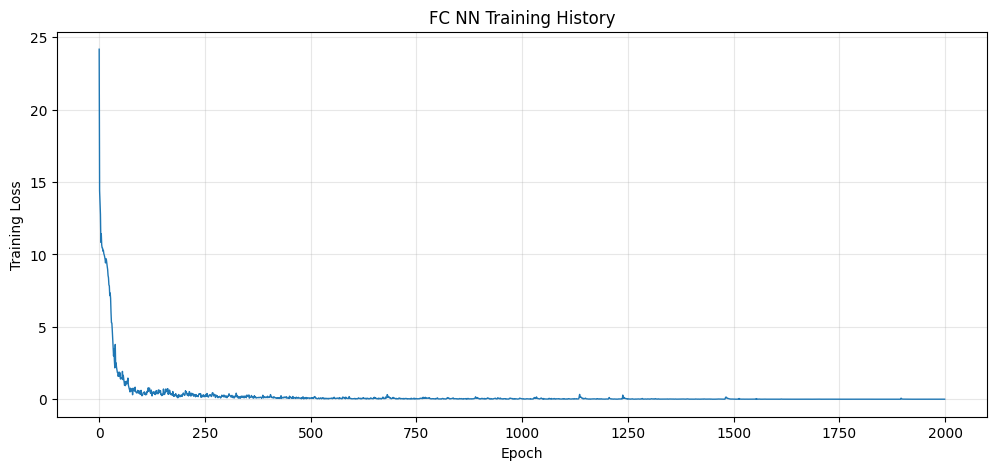

In [13]:
def plot_history():
    history_df = pd.DataFrame(model.history)

    plt.figure(figsize=(12, 5))
    plt.plot(history_df["epoch"], history_df["loss"], linewidth=1)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("FC NN Training History")
    plt.grid(True, alpha=0.3)
    plt.show()
    
plot_history()

In [14]:
def evaluate_model(model: FCNNRegressor,*,test_N: int = 10_000):
    X_test, y_test = training_data(test_N, seed=42)
    y_hat = model.predict(X_test)
    return calculate_metrics(y_test, y_hat)
    
evaluate_model(model)

{'rmse': 0.011383394167612072,
 'mae': 0.00933636428117752,
 'bias': 0.007921327793598176,
 'accuracy': 1.0,
 'accuracy_pm1': 1.0}

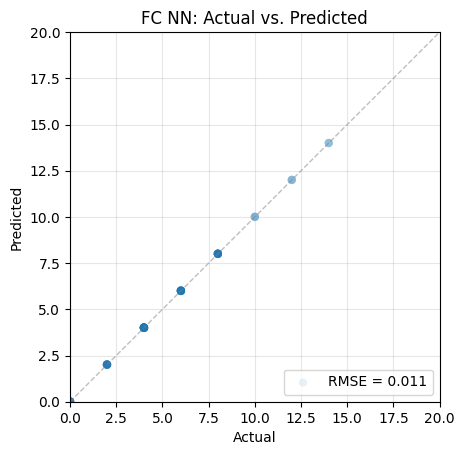

In [15]:
def plot_model_scatter(
    model,
    *,
    test_N: int = 200,
):
    X_test, y_test = training_data(test_N, seed=42)
    y_hat = model.predict(X_test)
    metrics = calculate_metrics(y_test, y_hat)

    # scatter plot
    alpha = min(1.0, 20 / test_N)
    label = (
        f"RMSE = {metrics['rmse']:.3f}"
#        f"Accuracy = {100 * metrics['accuracy']:.1f}%\n"
#        f"Accuracy ±1 = {100 * metrics['accuracy_pm1']:.1f}%"
    )
    plt.scatter(y_test, y_hat, alpha=alpha, edgecolors="none", label=label)

    # reference diagonal
    plt.axline(
        (0, 0),
        slope=1,
        linestyle="--",
        color="gray",
        alpha=0.5,
        lw=1,
    )

    plt.xlim(0, 20)
    plt.ylim(0, 20)

    # chart junk
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.legend(loc="lower right")
    plt.title("FC NN: Actual vs. Predicted")

    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True, alpha=0.3)

plot_model_scatter(model)

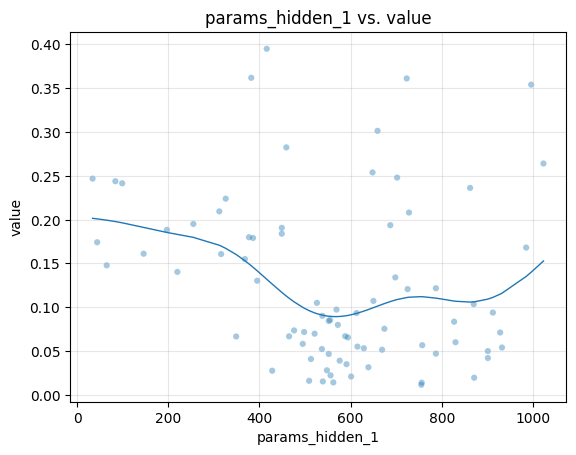

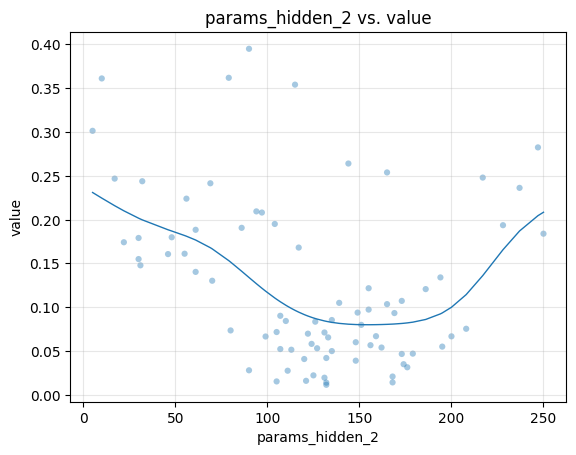

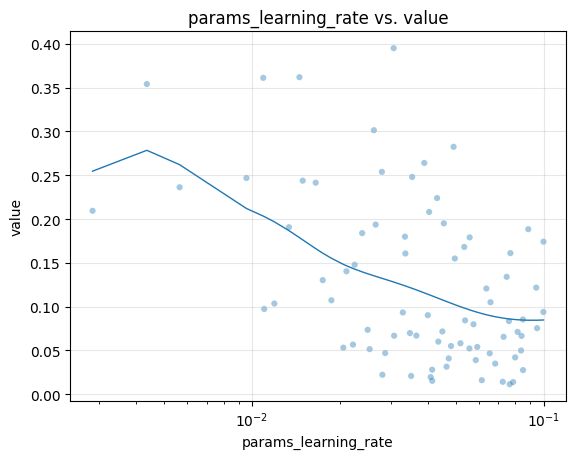

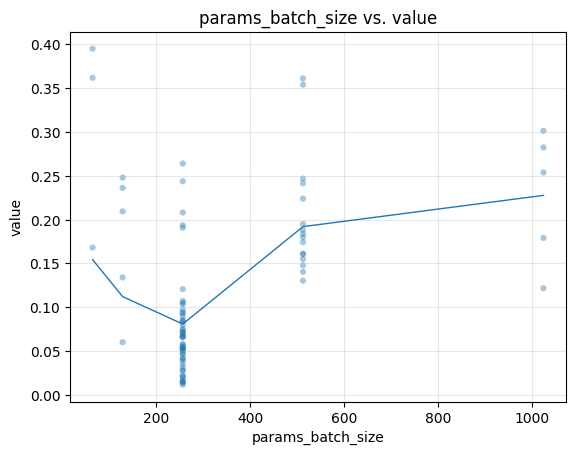

In [47]:
def plot_hyperparameter(
    trials_df: pd.DataFrame,
    hyperparameter: str,
    target: str = "value",
    *,
    log_x: bool = False,
    bandwidth: float | None = None,
    bandwidth_fraction: float = 0.1,
    greater_is_better: bool = False,
    remove_bottom: float = 0.1,
) -> None:
    df = trials_df[[hyperparameter, target]].dropna()

    if greater_is_better:
        cutoff = df[target].quantile(remove_bottom)
        df = df[df[target] >= cutoff]
    else:
        cutoff = df[target].quantile(1-remove_bottom)
        df = df[df[target] <= cutoff]

    x = df[hyperparameter].to_numpy()
    y = df[target].to_numpy()

    x_smooth_space = np.log10(x) if log_x else x

    order = np.argsort(x_smooth_space)
    x = x[order]
    y = y[order]
    x_smooth_space = x_smooth_space[order]

    if bandwidth is None:
        bandwidth = bandwidth_fraction * (x_smooth_space.max() - x_smooth_space.min())

    y_smooth = np.empty_like(y)

    for i, xi in enumerate(x_smooth_space):
        weights = np.exp(-0.5 * ((x_smooth_space - xi) / bandwidth) ** 2)
        y_smooth[i] = np.sum(weights * y) / np.sum(weights)

    plt.figure()
    plt.title(f"{hyperparameter} vs. {target}")
    plt.xlabel(hyperparameter)
    plt.ylabel(target)

    if log_x:
        plt.xscale("log")

    plt.scatter(x, y, alpha=0.4, s=20, edgecolors="none")
    plt.plot(x, y_smooth, linewidth=1)

    plt.grid(True, alpha=0.3)


for hyperparameter in [
    "params_hidden_1",
    "params_hidden_2",
    "params_learning_rate",
    "params_batch_size",
]:
    plot_hyperparameter(
        study.trials_dataframe(),
        hyperparameter,
        log_x=(hyperparameter == "params_learning_rate"),
        bandwidth_fraction=0.1,
        remove_bottom=0.2,
    )

In [33]:
study.trials_dataframe().columns

Index(['number', 'value', 'datetime_start', 'datetime_complete', 'duration',
       'params_activation', 'params_batch_size', 'params_hidden_1',
       'params_hidden_2', 'params_learning_rate', 'user_attrs_accuracy',
       'user_attrs_accuracy_pm1', 'user_attrs_bias', 'user_attrs_mae',
       'user_attrs_rmse', 'state'],
      dtype='object')

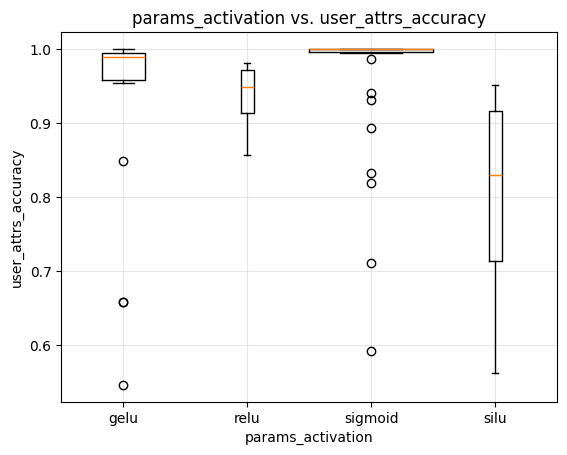

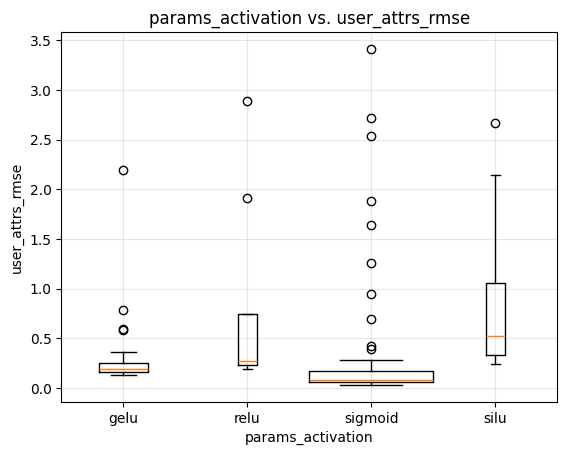

In [44]:
def plot_categorical_hyperparameter(
    trials_df: pd.DataFrame,
    hyperparameter: str,
    target: str = "value",
    greater_is_better: bool = False,
    remove_bottom: float = 0.1,
) -> None:
    df = trials_df[[hyperparameter, target]].dropna()

    if greater_is_better:
        cutoff = df[target].quantile(remove_bottom)
        df = df[df[target] >= cutoff]
    else:
        cutoff = df[target].quantile(1-remove_bottom)
        df = df[df[target] <= cutoff]

    grouped = df.groupby(hyperparameter)[target]
    categories = list(grouped.groups.keys())
    values = [group for _, group in grouped]
    counts = grouped.size().to_numpy()

    plt.title(f"{hyperparameter} vs. {target}")
    plt.xlabel(hyperparameter)
    plt.ylabel(target)

    plt.boxplot(
        values,
        labels=categories,
        widths=counts / counts.max(),
        showmeans=False,
    )
    plt.grid(True, alpha=0.3)

plot_categorical_hyperparameter(
    study.trials_dataframe(),
    "params_activation",
    target="user_attrs_accuracy",
    greater_is_better=True,
)
plt.show()

plot_categorical_hyperparameter(
    study.trials_dataframe(),
    "params_activation",
    target="user_attrs_rmse",
    greater_is_better=True,
)

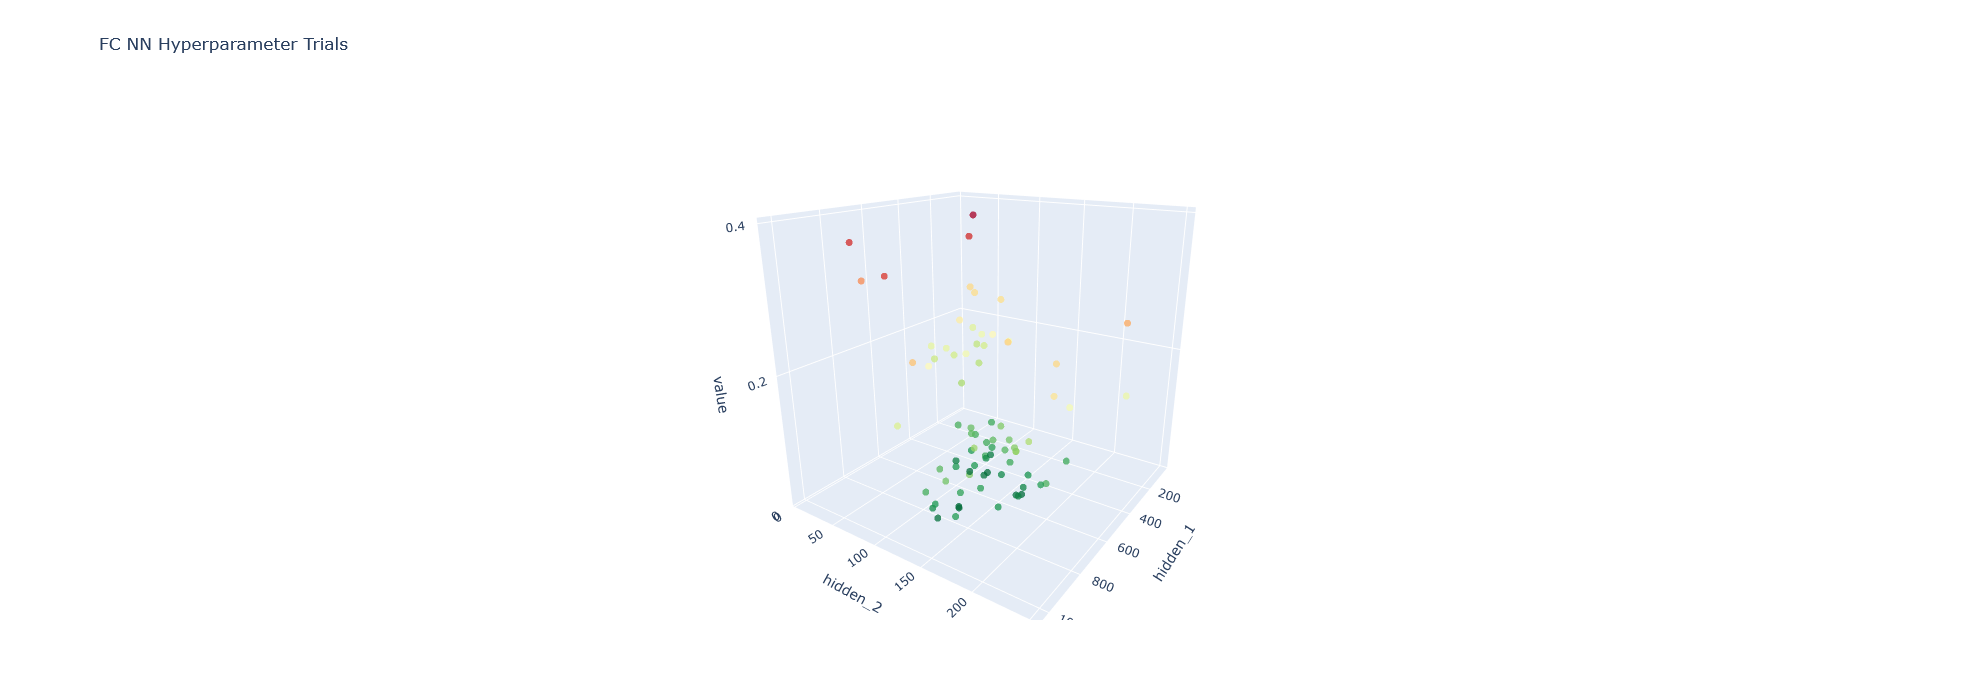

In [21]:
def plot_hidden_layer_trials_3d(
    study,
    *,
    target="value",
    title="FC NN Hyperparameter Trials",
):
    trials_df = study.trials_dataframe()

    df = trials_df[["params_hidden_1", "params_hidden_2", "value"]].dropna()
    cutoff = df[target].quantile(0.80)
    df = df[df[target] <= cutoff]

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=df["params_hidden_1"],
                y=df["params_hidden_2"],
                z=df["value"],
                mode="markers",
                marker=dict(
                    size=4,
                    color=df["value"],
                    colorscale="RdYlGn",
                    reversescale=True,
                    opacity=0.75,
                ),
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="hidden_1",
            yaxis_title="hidden_2",
            zaxis_title=target,
        ),
        width=900,
        height=700,
    )

    fig.show()

plot_hidden_layer_trials_3d(study)

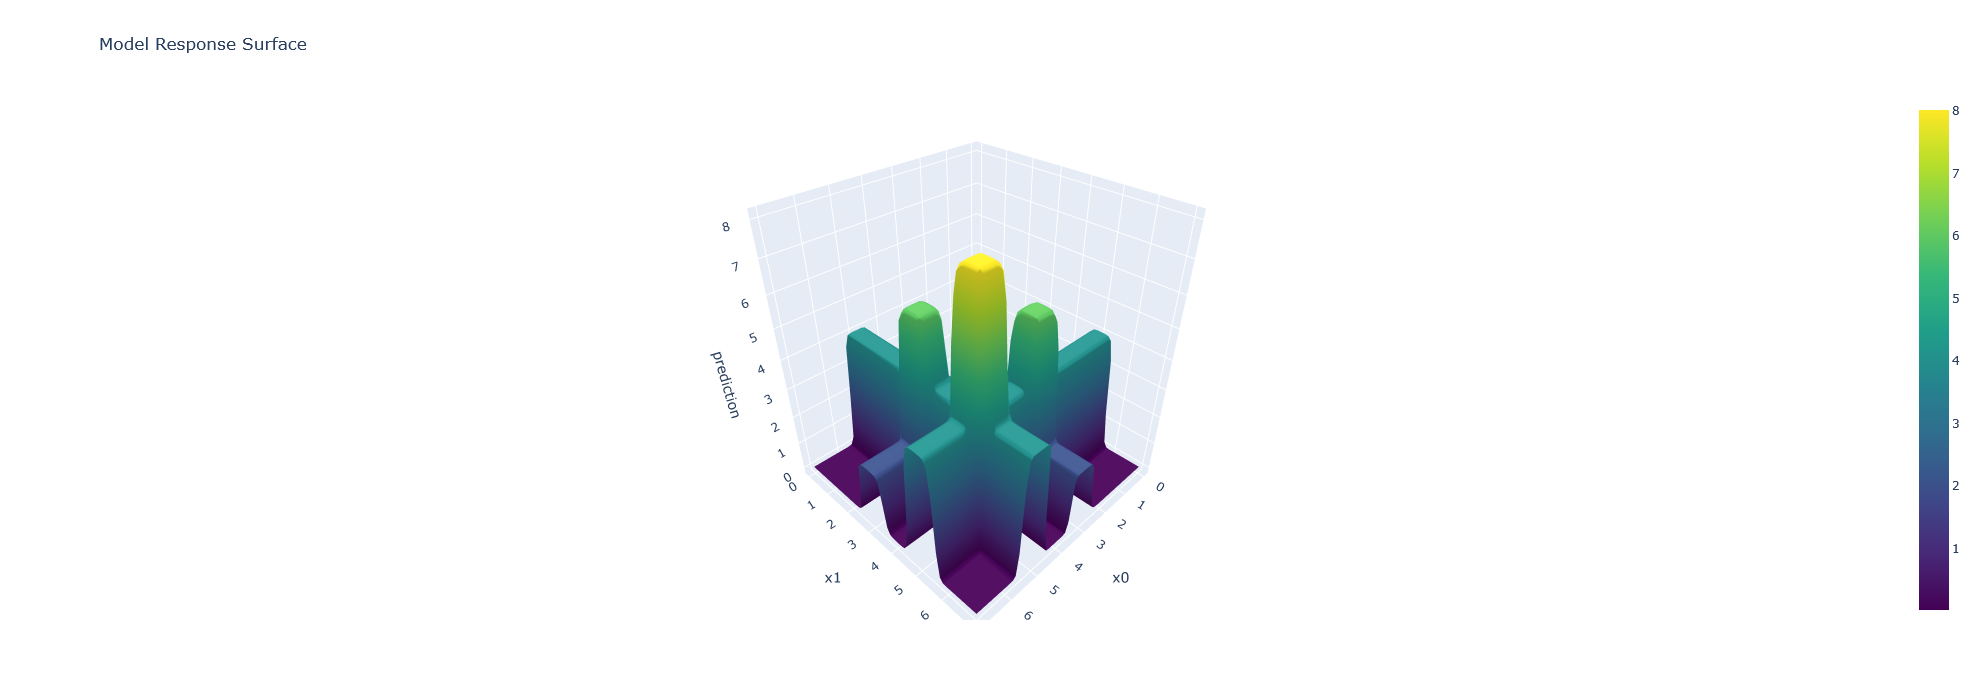

In [50]:
def plot_response_surface(
    model,
    *,
    fixed_values=(1, 1, 1),
    x_index=0,
    y_index=1,
    title="Model Response Surface",
    colorscale="Viridis",
):
    xs = np.arange(0, 7.01, 0.1)
    ys = np.arange(0, 7.01, 0.1)

    X, Y = np.meshgrid(xs, ys)

    points = np.ones((X.size, 5), dtype=float)

    fixed_iter = iter(fixed_values)

    for i in range(5):
        if i == x_index:
            points[:, i] = X.ravel()
        elif i == y_index:
            points[:, i] = Y.ravel()
        else:
            points[:, i] = next(fixed_iter)

    Z = model.predict(points).reshape(X.shape)

    fig = go.Figure(
        data=[
            go.Surface(
                x=X,
                y=Y,
                z=Z,
                colorscale=colorscale,
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title=f"x{x_index}",
            yaxis_title=f"x{y_index}",
            zaxis_title="prediction",
        ),
        width=900,
        height=700,
    )

    fig.show()

plot_response_surface(model)